# NSL-KDD Intrusion Detection - Binary Classification (Normal vs Attack)
### Versi binary dari pipeline multi-class. Konsep pipeline tetap sama:
- Preprocessing (LabelEncoder per kolom, StandardScaler)
- **Elbow Method** untuk cari k optimal
- KMeans Cluster-Based Undersampling (k cluster, sample banyak per cluster)
- BorderlineSMOTE untuk minority class
- XGBoost classifier
- SHAP feature importance + retrain Top-N
- Hyperparameter tuning

**Strategi sampling:** target 65.000 per class (sama dengan versi UNSW)

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score

from imblearn.over_sampling import BorderlineSMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
import shap
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [ ]:
train = pd.read_csv("kdd_train.csv", header=None)
test = pd.read_csv("kdd_test.csv", header=None)

columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label"
]

train.columns = columns
test.columns = columns

train = train.iloc[1:].copy()
test = test.iloc[1:].copy()

## 2. Binary Label Mapping
### CHANGE: label di-mapping ke binary -> 0 (Normal) atau 1 (Attack)
Semua label selain 'normal' dianggap attack.

In [ ]:
# Mapping binary: normal vs attack
def map_binary(label):
    if label == 'normal':
        return 0   # Normal
    else:
        return 1   # Attack (semua jenis: DoS, Probe, R2L, U2R, dll)

train['label'] = train['label'].apply(map_binary)
test['label']  = test['label'].apply(map_binary)

X_train = train.drop(columns=["label"])
y_train = train["label"]

X_test = test.drop(columns=["label"])
y_test = test["label"]

print("Train distribution:", Counter(y_train))
print("Test distribution :", Counter(y_test))
print("\n0 = Normal, 1 = Attack")

Train distribution: Counter({0: 67343, 1: 58630})
Test distribution : Counter({1: 11299, 0: 11245})

0 = Normal, 1 = Attack


## 3. Preprocessing
### LabelEncoder disimpan per kolom dalam dict agar tidak tertimpa

In [ ]:
categorical_cols = ["protocol_type", "service", "flag"]

# simpan setiap encoder dalam dict, bukan variabel tunggal yang ditimpa
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    # Handle unseen categories di test set
    X_test[col] = X_test[col].apply(
        lambda x: x if x in le.classes_ else le.classes_[0]
    )
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le  # simpan encoder per kolom

print("Categorical encoding done. Encoders saved:", list(label_encoders.keys()))

Categorical encoding done. Encoders saved: ['protocol_type', 'service', 'flag']


## 4. Scaling (Full Features)
### Untuk binary, target sudah 0/1, jadi tidak perlu LabelEncoder lagi untuk target

In [ ]:
# Scaling - fit hanya dari X_train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Target binary - langsung pakai
y_train_bin = y_train.values
y_test_bin  = y_test.values

class_names = ['Normal', 'Attack']

print("Classes:", class_names)
print("X_train_scaled shape:", X_train_scaled.shape)
print("Class balance train:", Counter(y_train_bin))

Classes: ['Normal', 'Attack']
X_train_scaled shape: (125973, 41)
Class balance train: Counter({np.int64(0): 67343, np.int64(1): 58630})


## 5. Baseline: XGBoost tanpa Sampling (Unbalanced)

In [ ]:
print("Training baseline XGBoost (unbalanced)...")

# CHANGE: binary -> objective='binary:logistic', eval_metric='logloss'
model_xgb_unbalanced = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss', random_state=42, n_jobs=-1
)
model_xgb_unbalanced.fit(X_train_scaled, y_train_bin)
y_pred_unbalanced  = model_xgb_unbalanced.predict(X_test_scaled)
y_proba_unbalanced = model_xgb_unbalanced.predict_proba(X_test_scaled)[:, 1]

print("\n=== Baseline (Unbalanced) ===")
print(classification_report(y_test_bin, y_pred_unbalanced,
                             target_names=class_names))
print(f"ROC-AUC : {roc_auc_score(y_test_bin, y_proba_unbalanced):.4f}")
print("Confusion matrix:")
print(confusion_matrix(y_test_bin, y_pred_unbalanced))

Training baseline XGBoost (unbalanced)...

=== Baseline (Unbalanced) ===
              precision    recall  f1-score   support

      Normal       0.90      0.99      0.94     11245
      Attack       0.99      0.89      0.93     11299

    accuracy                           0.94     22544
   macro avg       0.94      0.94      0.94     22544
weighted avg       0.94      0.94      0.94     22544

ROC-AUC : 0.9932
Confusion matrix:
[[11153    92]
 [ 1299 10000]]


## 6. Hybrid Sampling: KMeans Undersampling + BorderlineSMOTE
### Distribusi NSL-KDD KDDTrain+ (binary):
- Normal (0): ~67.343  → di-UNDERSAMPLE ke 65.000
- Attack (1): ~58.630  → di-SMOTE ke 65.000

**NEW:** Pakai elbow method untuk cari k optimal per class, lalu sample (target_n // k) sampel per cluster — sama persis dengan versi UNSW.

### 6.1 Elbow untuk class Normal (majority — yang akan di-undersample)

Jumlah sample class Normal (0): 67343


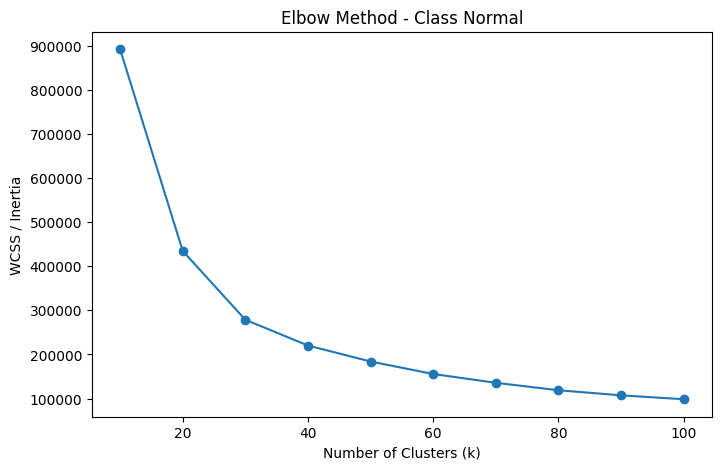

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_values = []

k_range = range(10, 101, 10)

X_normal = X_train_scaled[y_train_bin == 0]

print(f"Jumlah sample class Normal (0): {len(X_normal)}")

for k in k_range:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_normal)

    inertia_values.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(k_range, inertia_values, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method - Class Normal")

plt.show()

### 6.2 Elbow untuk class Attack (untuk konsistensi, walaupun nanti di-SMOTE)

In [ ]:
inertia_values = []

k_range = range(10, 101, 10)

X_attack = X_train_scaled[y_train_bin == 1]

print(f"Jumlah sample class Attack (1): {len(X_attack)}")

for k in k_range:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_attack)

    inertia_values.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(k_range, inertia_values, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method - Class Attack")

plt.show()

### 6.3 KMeans Undersample function (sama persis dengan versi UNSW)

In [ ]:
def kmeans_undersample(
    X,
    y,
    sampling_strategy,
    cluster_strategy,
    random_state=42
):

    X_result, y_result = [], []

    unique_classes = np.unique(y)

    rng = np.random.RandomState(random_state)

    for cls in unique_classes:

        # =====================================================
        # AMBIL DATA PER CLASS
        # =====================================================
        mask = (y == cls) if not hasattr(y, 'values') else (y.values == cls)

        X_cls = X[mask]

        # target jumlah setelah undersampling
        target_n = sampling_strategy.get(cls, len(X_cls))

        # jumlah cluster khusus tiap class
        n_cluster_cls = cluster_strategy.get(cls, 50)

        # =====================================================
        # MINORITY CLASS -> AMBIL SEMUA
        # =====================================================
        if len(X_cls) <= target_n:

            X_result.append(X_cls)
            y_result.extend([cls] * len(X_cls))

        # =====================================================
        # MAJORITY CLASS -> KMEANS CLUSTER SAMPLING
        # =====================================================
        else:

            print(f"\nClass : {cls}")
            print(f"Original samples : {len(X_cls)}")
            print(f"Target samples   : {target_n}")
            print(f"Clusters used    : {n_cluster_cls}")

            # KMeans clustering
            km = KMeans(
                n_clusters=n_cluster_cls,
                random_state=random_state,
                n_init=10,
                max_iter=300
            )

            cluster_labels = km.fit_predict(X_cls)

            # jumlah sampel yang diambil per cluster
            samples_per_cluster = target_n // n_cluster_cls

            selected_indices = []

            # =====================================================
            # SAMPLING TIAP CLUSTER
            # =====================================================
            for cluster_id in range(n_cluster_cls):

                cluster_idx = np.where(cluster_labels == cluster_id)[0]

                # jika isi cluster <= target per cluster
                if len(cluster_idx) <= samples_per_cluster:

                    selected_indices.extend(cluster_idx)

                else:

                    chosen = rng.choice(
                        cluster_idx,
                        size=samples_per_cluster,
                        replace=False
                    )

                    selected_indices.extend(chosen)

            selected_indices = np.array(selected_indices)

            # =====================================================
            # JIKA JUMLAH MASIH KURANG
            # =====================================================
            if len(selected_indices) < target_n:

                remaining = np.setdiff1d(
                    np.arange(len(X_cls)),
                    selected_indices
                )

                extra = rng.choice(
                    remaining,
                    size=target_n - len(selected_indices),
                    replace=False
                )

                selected_indices = np.concatenate([
                    selected_indices,
                    extra
                ])

            X_result.append(X_cls[selected_indices])

            y_result.extend([cls] * len(selected_indices))

    # =====================================================
    # GABUNGKAN SEMUA CLASS
    # =====================================================
    X_out = np.vstack(X_result)
    y_out = np.array(y_result)

    return X_out, y_out


# =========================================================
# STEP 1 : KMEANS CLUSTER-BASED UNDERSAMPLING
# =========================================================
# Target binary: PERTEMUKAN di 65.000 per class
# - Normal (0) ~67K  -> di-UNDERSAMPLE ke 65K via KMeans
# - Attack (1) ~58K  -> dibiarkan dulu (akan di-SMOTE di Step 2)
#
# Fungsi kmeans_undersample sudah handle: kalau jumlah class <= target,
# class tsb di-pass-through tanpa undersampling (lihat branch "MINORITY").

print("Step 1: KMeans Cluster-Based Undersampling")
print(f"Distribusi awal: {Counter(y_train_bin)}")

TARGET_PER_CLASS = 65000

# CHANGE: target binary 0/1 -> dua-duanya 65K
# Normal akan benar2 di-undersample, Attack akan di-pass-through (krn <65K)
sampling_strategy_under = {
    0: TARGET_PER_CLASS,   # Normal (~67K -> undersample ke 65K)
}

# Jumlah cluster KMeans per class (sesuaikan dengan hasil elbow di atas)
cluster_strategy = {
    0: 40,
}

X_under, y_under = kmeans_undersample(

    X_train_scaled,
    y_train_bin,

    sampling_strategy=sampling_strategy_under,
    cluster_strategy=cluster_strategy,

    random_state=42
)

print("\nAfter KMeans Undersampling:")
print(Counter(y_under))


# =========================================================
# STEP 2 : BORDERLINE SMOTE
# =========================================================
# Setelah Step 1: Normal=65K, Attack=~58K (belum diubah)
# SMOTE Attack -> 65K supaya seimbang

print("\nStep 2: BorderlineSMOTE")

smote = BorderlineSMOTE(
    kind='borderline-2',
    sampling_strategy={
        1: TARGET_PER_CLASS,   # Attack -> 65K
    },
    k_neighbors=3,
    random_state=42
)

X_res, y_res = smote.fit_resample(X_under, y_under)

print("\nAfter BorderlineSMOTE:")
print(Counter(y_res))

Step 1: KMeans Cluster-Based Undersampling
Distribusi awal: Counter({np.int64(0): 67343, np.int64(1): 58630})

Class : 0
Original samples : 67343
Target samples   : 65000
Clusters used    : 40

After KMeans Undersampling:
Counter({np.int64(0): 65000, np.int64(1): 58630})

Step 2: BorderlineSMOTE

After BorderlineSMOTE:
Counter({np.int64(0): 65000, np.int64(1): 65000})


## 7. XGBoost dengan Hybrid Sampling (Full 41 Features)

In [ ]:
# CHANGE: y_res sudah binary 0/1, tidak perlu label_encoder lagi
model_xgb = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss', random_state=42, n_jobs=-1
)
model_xgb.fit(X_res, y_res)

y_pred_xgb  = model_xgb.predict(X_test_scaled)
y_proba_xgb = model_xgb.predict_proba(X_test_scaled)[:, 1]

print("=== XGBoost + Hybrid Sampling (41 Features) ===")
print(classification_report(y_test_bin, y_pred_xgb,
                             target_names=class_names))
print(f"ROC-AUC : {roc_auc_score(y_test_bin, y_proba_xgb):.4f}")
print("Confusion matrix:")
print(confusion_matrix(y_test_bin, y_pred_xgb))

=== XGBoost + Hybrid Sampling (41 Features) ===
              precision    recall  f1-score   support

      Normal       0.90      0.99      0.94     11245
      Attack       0.99      0.89      0.94     11299

    accuracy                           0.94     22544
   macro avg       0.95      0.94      0.94     22544
weighted avg       0.95      0.94      0.94     22544

ROC-AUC : 0.9939
Confusion matrix:
[[11151    94]
 [ 1215 10084]]


## 8. SHAP Analysis

Calculating SHAP values from TRAINING set (X_res)...
Note: SHAP dihitung dari training set agar tidak terjadi information leakage
SHAP values shape: (5000, 41)
Generating SHAP summary plot...


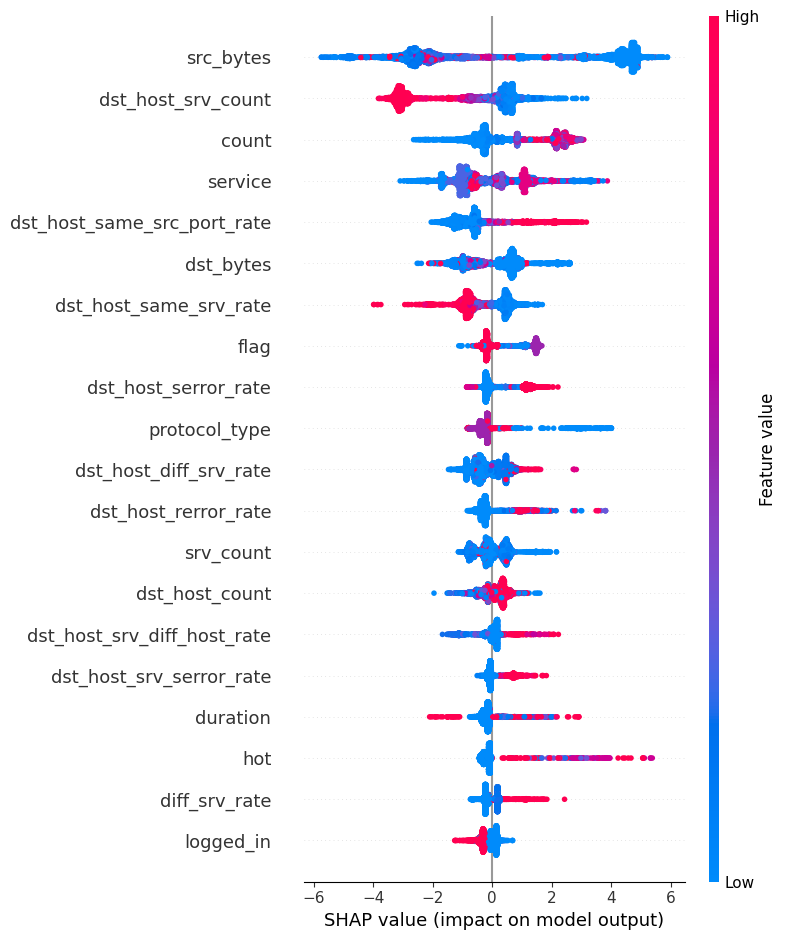

In [ ]:
import shap

print("Calculating SHAP values from TRAINING set (X_res)...")
print("Note: SHAP dihitung dari training set agar tidak terjadi information leakage")

explainer = shap.TreeExplainer(model_xgb)

# Gunakan subsample agar lebih cepat jika data besar
shap_sample_size = min(5000, X_res.shape[0])
np.random.seed(42)
shap_indices = np.random.choice(X_res.shape[0], shap_sample_size, replace=False)
X_shap = X_res[shap_indices]

shap_values = explainer.shap_values(X_shap)

feature_names = X_train.columns.tolist()

print(f"SHAP values shape: {np.array(shap_values).shape}")
print("Generating SHAP summary plot...")

# CHANGE: binary -> tidak perlu class_names di summary_plot
shap.summary_plot(shap_values, X_shap, feature_names=feature_names)

## 9. Feature Ranking dari SHAP

In [ ]:
shap_array = np.array(shap_values)

# CHANGE: binary classification -> shape (n_samples, n_features), bukan 3D
if shap_array.ndim == 3:
    # fallback kalau format lama (n_classes, n_samples, n_features)
    mean_abs_shap = np.mean(np.abs(shap_array), axis=(0, 1))
else:
    # binary -> (n_samples, n_features)
    mean_abs_shap = np.mean(np.abs(shap_array), axis=0)

feature_importance = dict(zip(feature_names, mean_abs_shap))
sorted_feature_importance = sorted(feature_importance.items(),
                                    key=lambda x: x[1], reverse=True)

print("\nTop 15 Features by Mean |SHAP| (from training set):")
for i, (feat, imp) in enumerate(sorted_feature_importance[:15], 1):
    print(f"{i:2d}. {feat}: {imp:.4f}")


Top 15 Features by Mean |SHAP| (from training set):
 1. src_bytes: 3.1621
 2. dst_host_srv_count: 1.3783
 3. count: 1.1013
 4. service: 0.9829
 5. dst_host_same_src_port_rate: 0.8991
 6. dst_bytes: 0.7833
 7. dst_host_same_srv_rate: 0.6717
 8. flag: 0.6258
 9. dst_host_serror_rate: 0.4732
10. protocol_type: 0.4680
11. dst_host_diff_srv_rate: 0.4504
12. dst_host_rerror_rate: 0.4333
13. srv_count: 0.3855
14. dst_host_count: 0.3428
15. dst_host_srv_diff_host_rate: 0.2674


## 10. Retrain dengan Top N Features
### Pipeline konsisten: SHAP (dari train) → filter fitur → scale → KMeans Undersample → SMOTE → train

In [ ]:
# =====================================================
# CLUSTER STRATEGY HASIL ELBOW
# =====================================================

cluster_strategy = {
    0: 40,
}

results   = {}
all_preds = {}

for top_n in [10, 20, 30]:

    print(f"\n{'='*55}")
    print(f" Processing Top {top_n} Features")
    print(f"{'='*55}")

    # =====================================================
    # TOP FEATURES
    # =====================================================

    top_features = [
        feat for feat, _ in sorted_feature_importance[:top_n]
    ]

    print(f"  Features: {top_features}")

    # =====================================================
    # FILTER FEATURE
    # =====================================================

    X_train_top = X_train[top_features]
    X_test_top  = X_test[top_features]

    # =====================================================
    # SCALING
    # =====================================================

    scaler_top = StandardScaler()

    X_train_top_scaled = scaler_top.fit_transform(X_train_top)
    X_test_top_scaled  = scaler_top.transform(X_test_top)

    # =====================================================
    # KMEANS UNDERSAMPLING
    # =====================================================

    X_under_top, y_under_top = kmeans_undersample(

        X_train_top_scaled,
        y_train_bin,

        sampling_strategy=sampling_strategy_under,
        cluster_strategy=cluster_strategy,

        random_state=42
    )

    print(f"  After KMeans Undersampling:")
    print(Counter(y_under_top))

    # =====================================================
    # BORDERLINE SMOTE (binary) - SMOTE Attack ke 65K
    # =====================================================

    smote_top = BorderlineSMOTE(
        kind='borderline-2',
        sampling_strategy={
            1: TARGET_PER_CLASS,   # Attack -> 65K
        },
        k_neighbors=3,
        random_state=42
    )

    X_res_top, y_res_top = smote_top.fit_resample(
        X_under_top, y_under_top
    )

    print(f"  After SMOTE:")
    print(Counter(y_res_top))

    # =====================================================
    # XGBOOST (binary)
    # =====================================================

    model_top = XGBClassifier(

        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,

        subsample=0.8,
        colsample_bytree=0.8,

        objective='binary:logistic',
        eval_metric='logloss',

        random_state=42,
        n_jobs=-1
    )

    model_top.fit(X_res_top, y_res_top)

    # =====================================================
    # PREDICTION
    # =====================================================

    y_pred_top  = model_top.predict(X_test_top_scaled)
    y_proba_top = model_top.predict_proba(X_test_top_scaled)[:, 1]

    all_preds[top_n] = {
        'y_pred'         : y_pred_top,
        'y_proba'        : y_proba_top,
        'model'          : model_top,
        'X_test_scaled'  : X_test_top_scaled,
        'X_res'          : X_res_top,
        'y_res'          : y_res_top,
        'top_features'   : top_features,
        'scaler'         : scaler_top,
    }

    # =====================================================
    # EVALUATION
    # =====================================================

    report = classification_report(

        y_test_bin,
        y_pred_top,

        target_names=class_names,

        output_dict=True
    )

    results[f'top_{top_n}'] = report

    print(f"\n  Classification Report (Top {top_n} Features):")
    print(classification_report(y_test_bin, y_pred_top,
                                 target_names=class_names))
    print(f"  ROC-AUC : {roc_auc_score(y_test_bin, y_proba_top):.4f}")


 Processing Top 10 Features
  Features: ['src_bytes', 'dst_host_srv_count', 'count', 'service', 'dst_host_same_src_port_rate', 'dst_bytes', 'dst_host_same_srv_rate', 'flag', 'dst_host_serror_rate', 'protocol_type']

Class : 0
Original samples : 67343
Target samples   : 65000
Clusters used    : 40
  After KMeans Undersampling:
Counter({np.int64(0): 65000, np.int64(1): 58630})
  After SMOTE:
Counter({np.int64(0): 65000, np.int64(1): 65000})

  Classification Report (Top 10 Features):
              precision    recall  f1-score   support

      Normal       0.89      0.99      0.94     11245
      Attack       0.99      0.87      0.93     11299

    accuracy                           0.93     22544
   macro avg       0.94      0.93      0.93     22544
weighted avg       0.94      0.93      0.93     22544

  ROC-AUC : 0.9914

 Processing Top 20 Features
  Features: ['src_bytes', 'dst_host_srv_count', 'count', 'service', 'dst_host_same_src_port_rate', 'dst_bytes', 'dst_host_same_srv_rate',

## 11. Hyperparameter Tuning (pada konfigurasi terbaik)

In [ ]:
# Ganti top_n_best sesuai hasil eksperimen di atas
top_n_best = 30

best_data         = all_preds[top_n_best]
X_res_best        = best_data['X_res']
y_res_best        = best_data['y_res']
X_test_best_scaled = best_data['X_test_scaled']

print(f"Data untuk tuning: {X_res_best.shape}")
print(f"Label distribution: {Counter(y_res_best)}")

Data untuk tuning: (130000, 30)
Label distribution: Counter({np.int64(0): 65000, np.int64(1): 65000})


In [ ]:
param_dist = {
    'n_estimators'    : [200, 300, 500, 700],
    'max_depth'       : [4, 6, 8, 10],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma'           : [0, 0.1, 0.3],
    'min_child_weight': [1, 3, 5],
}

# CHANGE: binary -> objective='binary:logistic', eval_metric='logloss'
xgb_tune = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42, n_jobs=-1
)

# CHANGE: scoring untuk binary -> 'f1' (di multiclass dipakai recall_macro)
random_search = RandomizedSearchCV(
    estimator=xgb_tune,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1',          # binary F1 - bisa diganti 'roc_auc' kalau mau
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

print("Starting RandomizedSearchCV...")
random_search.fit(X_res_best, y_res_best)
print("Finished.")

best_model = random_search.best_estimator_
print("Best params:", random_search.best_params_)
print("Best F1 (CV):", random_search.best_score_)

y_pred_tuned  = best_model.predict(X_test_best_scaled)
y_proba_tuned = best_model.predict_proba(X_test_best_scaled)[:, 1]

Starting RandomizedSearchCV...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Finished.
Best params: {'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.7}
Best F1 (CV): 0.9761475068839318


## 12. Perbandingan Semua Model

In [ ]:
import pandas as pd

def get_summary(y_true, y_pred, y_proba, model_name):
    """CHANGE: untuk binary - tambah ROC-AUC, metric per class Normal/Attack"""
    report = classification_report(y_true, y_pred,
                                    target_names=class_names,
                                    output_dict=True)
    return {
        'Model'        : model_name,
        'Accuracy'     : round(report['accuracy'], 4),
        'Precision'    : round(report['macro avg']['precision'], 4),
        'Recall'       : round(report['macro avg']['recall'], 4),
        'F1 Macro'     : round(report['macro avg']['f1-score'], 4),
        'F1 Normal'    : round(report['Normal']['f1-score'], 4),
        'F1 Attack'    : round(report['Attack']['f1-score'], 4),
        'ROC-AUC'      : round(roc_auc_score(y_true, y_proba), 4),
    }

# Kumpulkan prediksi dari semua model
# y_pred_top adalah prediksi dari iterasi top_n=30 (iterasi terakhir loop)
rows = [
    get_summary(y_test_bin, y_pred_unbalanced, y_proba_unbalanced,
                'Baseline (No Sampling)'),
    get_summary(y_test_bin, y_pred_xgb,         y_proba_xgb,
                'Hybrid Sampling (41 Fitur)'),
    get_summary(y_test_bin, y_pred_top,         y_proba_top,
                f'Hybrid + Top {top_n} Fitur (last loop)'),
    get_summary(y_test_bin, y_pred_tuned,       y_proba_tuned,
                f'Hybrid + Top {top_n_best} + Tuning'),
]

df_compare = pd.DataFrame(rows)
print("\n=== Perbandingan Semua Model (Binary Classification) ===")
print(df_compare.to_string(index=False))


=== Perbandingan Semua Model (Binary Classification) ===
                            Model  Accuracy  Precision  Recall  F1 Macro  F1 Normal  F1 Attack  ROC-AUC
           Baseline (No Sampling)    0.9383     0.9433  0.9384    0.9381     0.9413     0.9350   0.9932
       Hybrid Sampling (41 Fitur)    0.9419     0.9463  0.9421    0.9418     0.9446     0.9391   0.9939
Hybrid + Top 30 Fitur (last loop)    0.9408     0.9453  0.9409    0.9407     0.9436     0.9378   0.9928
         Hybrid + Top 30 + Tuning    0.9373     0.9424  0.9374    0.9371     0.9404     0.9338   0.9933
